# Week 9, Lab \#8

*March 11, 2026*

In this course we've been working with vegetation indices like the Normalized Difference Greenness Index (NDGI) and Normalized Difference Vegetation Index (NDVI). These vegetation indices (VI) are sensitive to changes in green leaf cover or vigor and can be used to quantify the status of green vegetation. 

If a time series of VI were available, we could, in theory, quantify changes in green vegetation cover or vigor over time. This is an important application of remote sensing because terrestrial vegetation may serve as an indicator of several trends in the terrestrial biosphere:

- Changes in water availability (soil moisture) will affect vegetation in semi-arid regions.
- Changes in temperature also affect vegetation status: Short-term extremes like heat waves can damage vegetation while long-term warming trends might extend the growing season and improve vegetation growth or vigor at high latitudes or high elevations.
- At high latitudes, in particular, warmer conditions and thawing soils have led to the encroachment of woody shrubs on former grasslands; the shrubs tend to have more and greener leaf cover, so this can show up as an increase in greenness.
- Increasing CO$_2$ levels in the atmosphere can also lead to a "fertilization effect," whereby vegetation, particularly trees, can absorb more carbon from the atmosphere while losing less water, potentially accelerating their growth rates.

**Today, we'll use [NDVI data from the MODIS sensor aboard the Terra satellite](https://lpdaac.usgs.gov/products/mod13a1v061/) to analyze greenness trends over time. We'll look at a single MODIS tile that shows much of Alberta and British Columbia, Canada.**

[**Download the data and extract it to a folder where you can access it from this Notebook.**](http://files.ntsg.umt.edu/data/GIS_Programming/data/MOD13A1_Alberta.zip)

## The EOS-HDF4 Format

Before we get started analyzing the data, we need to familarize ourselves with the data format.

The MODIS MOD13A1 product that we're using today is currently only available in a hierarchical data file format, but not one that we've seen before: They're stored as EOS-HDF4 files, a special NASA file format based on an older HDF standard (HDF4). EOS-HDF4 can be difficult to work with and depending on how the file was created and the version of GDAL we have installed, we may not be able to read spatial information from the file. 

`gdal` can read from HDF4 (and HDF5) files. However, for hierarchical file types, there could be multiple different datasets contained within.

In [1]:
from osgeo import gdal

hdf = gdal.Open('data/MOD13A1.A2000193.h11v03.061.2020051154615.hdf')
for data in hdf.GetSubDatasets():
    print(data[0])

HDF4_EOS:EOS_GRID:"data/MOD13A1.A2000193.h11v03.061.2020051154615.hdf":MODIS_Grid_16DAY_500m_VI:"500m 16 days NDVI"
HDF4_EOS:EOS_GRID:"data/MOD13A1.A2000193.h11v03.061.2020051154615.hdf":MODIS_Grid_16DAY_500m_VI:"500m 16 days EVI"
HDF4_EOS:EOS_GRID:"data/MOD13A1.A2000193.h11v03.061.2020051154615.hdf":MODIS_Grid_16DAY_500m_VI:"500m 16 days VI Quality"
HDF4_EOS:EOS_GRID:"data/MOD13A1.A2000193.h11v03.061.2020051154615.hdf":MODIS_Grid_16DAY_500m_VI:"500m 16 days red reflectance"
HDF4_EOS:EOS_GRID:"data/MOD13A1.A2000193.h11v03.061.2020051154615.hdf":MODIS_Grid_16DAY_500m_VI:"500m 16 days NIR reflectance"
HDF4_EOS:EOS_GRID:"data/MOD13A1.A2000193.h11v03.061.2020051154615.hdf":MODIS_Grid_16DAY_500m_VI:"500m 16 days blue reflectance"
HDF4_EOS:EOS_GRID:"data/MOD13A1.A2000193.h11v03.061.2020051154615.hdf":MODIS_Grid_16DAY_500m_VI:"500m 16 days MIR reflectance"
HDF4_EOS:EOS_GRID:"data/MOD13A1.A2000193.h11v03.061.2020051154615.hdf":MODIS_Grid_16DAY_500m_VI:"500m 16 days view zenith angle"
HDF4_EOS:

First, let's close the dataset we just opened.

In [2]:
hdf = None

These **subdatasets** need to be loaded in a special way. We use *string formatting* in Python, below, to embed the filename into the larger dataset name, as GDAL expects.

In [3]:
some_string = 'good'
f'Have a {some_string} Lab!'

'Have a good Lab!'

In [4]:
'Have a {adjective} Lab!'.format(adjective = some_string)

'Have a good Lab!'

In [5]:
filename = 'data/MOD13A1.A2000193.h11v03.061.2020051154615.hdf'

ndvi = gdal.Open(f'HDF4_EOS:EOS_GRID:{filename}:MODIS_Grid_16DAY_500m_VI:"500m 16 days NDVI"')
ndvi.ReadAsArray()

array([[ -45,   -4, -143, ..., 6890, 7162, 6775],
       [  31,  223,  361, ..., 6812, 7331, 7159],
       [ 223, 2591, 4009, ..., 7167, 7091, 7107],
       ...,
       [6836, 7712, 7554, ..., 8149, 7800, 8000],
       [7323, 7554, 7786, ..., 7800, 7850, 7718],
       [7556, 7701, 6470, ..., 7443, 7592, 7095]], dtype=int16)

It's pretty verbose, but this is how `gdal` handles HDF and netCDF4 files.

## Reading and Plotting MODIS NDVI Data

Similar to the NDGI, the Normalized Difference Vegetation Index (NDVI) is a measure of green vegetation cover and vigor. NDVI is superior to NDGI, however, because it incorporates data on near-infrared (NIR) reflectance, which is more physically related to green leaves than visible green reflectance. This is because chlorophyll is strongly absorbing of Red light while the internal structure of leaves and stems tends to be highly reflective of NIR light.

$$
\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}
$$

Because NDVI is normalized, when correctly calculated the values fall between -1 and +1, inclusive, where positive values generally correspond to increasing vegetation greenness and negative values generally correspond to non-vegetation cover.

**The MODIS MOD13A1 product also includes a "pixel reliability" band that summarizes the state of each pixel** (see Table 4 of the User Guide).

In [6]:
qa = gdal.Open(f'HDF4_EOS:EOS_GRID:{filename}:MODIS_Grid_16DAY_500m_VI:"500m 16 days pixel reliability"')
qa = qa.ReadAsArray()

In [7]:
import numpy as np

np.unique(qa)

array([  0,   1,   2,   3, 255], dtype=uint8)

This is a kind of quality assurance (QA) band and the values are described below.

Value | Summary key   | Description                              |
------|--------------:|-----------------------------------------:|
-1    | No Data       | Not processed                            |
0     | Good data     | Use with confidence                      |
1     | Marginal data | Useful, but look at other QA information |
2     | Snow/Ice      | Target covered with snow or ice          |
3     | Cloudy        | Target covered by cloud                  |

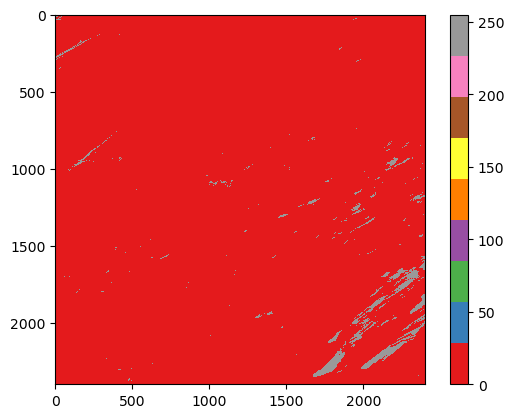

In [8]:
from matplotlib import pyplot

pyplot.imshow(np.where(qa == -1, 4, qa), cmap = 'Set1', interpolation = 'nearest')
pyplot.colorbar()

---

## Problem 8.1: Plotting MODIS NDVI

**Write a Python function (using `def` keyword) called `process_ndvi()` that:**

1. Accepts an MOD13A1 filename as an argument;
2. Opens the MOD13A1 file;
3. Reads in the NDVI and the "pixel reliability" data;
4. Sets pixels where the pixel reliability is not 0 or 1 to `NaN` (i.e., only "Good" or "Marginal" pixels should be used);
5. Returns a NumPy array of the masked NDVI data.

**Hint:** Make sure you know *how* to use these data! Think about NoData, data types, and valid ranges. [Take a look at the User Guide,](http://files.ntsg.umt.edu/data/GIS_Programming/docs/MOD13_User_Guide_V61.pdf) particularly Table 1 on Page 9.

**Hint:** As suggested in the previous hint, think particularly about: Do the data need to be re-scaled?

The result should look something like this:

from matplotlib import pyplot

pyplot.imshow(result, interpolation = 'nearest')
pyplot.colorbar()

---

Because this image is in the MODIS Sinusoidal projection, it's kind of hard to visualize, so I made this re-projected, north-up image (Lambert Conformal Conic projection) in QGIS, showing the land-cover distribution in this MODIS tile. Lake Winnepegosis can be seen at the lower-right of the image.

![](assets/MCD12Q1_h11v03.png)

**This is a good start, but there are some very low NDVI values in areas with permanent water bodies.** We also might want to mask out high-elevation areas of ice, snow, or barren rock.

Let's use another MODIS product, MCD12Q1 (source of the land-cover data above), contains a map of land cover that can be used to mask pixels based on their land-cover classification.

## Loading MCD12Q1 Data

MODIS products come as "tiles;" the entire Earth's surface is divided into large tiles and each product has data for each of the tiles, like the MOD13A1 example above. [**Download the corresponding MCD12Q1 tile data here.**](http://files.ntsg.umt.edu/data/GIS_Programming/data/MCD12Q1.A2015001.h11v03.006.hdf)

This is another EOS-HDF4 file with multiple datasets.

In [9]:
lc = gdal.Open('data/MCD12Q1.A2015001.h11v03.006.hdf')
lc.GetSubDatasets()

[('HDF4_EOS:EOS_GRID:"data/MCD12Q1.A2015001.h11v03.006.hdf":MCD12Q1:LC_Type1',
  '[2400x2400] LC_Type1 MCD12Q1 (8-bit unsigned integer)'),
 ('HDF4_EOS:EOS_GRID:"data/MCD12Q1.A2015001.h11v03.006.hdf":MCD12Q1:LC_Type2',
  '[2400x2400] LC_Type2 MCD12Q1 (8-bit unsigned integer)'),
 ('HDF4_EOS:EOS_GRID:"data/MCD12Q1.A2015001.h11v03.006.hdf":MCD12Q1:LC_Type3',
  '[2400x2400] LC_Type3 MCD12Q1 (8-bit unsigned integer)'),
 ('HDF4_EOS:EOS_GRID:"data/MCD12Q1.A2015001.h11v03.006.hdf":MCD12Q1:LC_Type4',
  '[2400x2400] LC_Type4 MCD12Q1 (8-bit unsigned integer)'),
 ('HDF4_EOS:EOS_GRID:"data/MCD12Q1.A2015001.h11v03.006.hdf":MCD12Q1:LC_Type5',
  '[2400x2400] LC_Type5 MCD12Q1 (8-bit unsigned integer)'),
 ('HDF4_EOS:EOS_GRID:"data/MCD12Q1.A2015001.h11v03.006.hdf":MCD12Q1:LC_Prop1_Assessment',
  '[2400x2400] LC_Prop1_Assessment MCD12Q1 (8-bit unsigned integer)'),
 ('HDF4_EOS:EOS_GRID:"data/MCD12Q1.A2015001.h11v03.006.hdf":MCD12Q1:LC_Prop2_Assessment',
  '[2400x2400] LC_Prop2_Assessment MCD12Q1 (8-bit unsi

The land-cover map we'll use today is "Type 5" (global Plant Functional Type or PFT map):

Type                              | Code |
----------------------------------|------|
Water bodies                      | 0    |
Evergreen needleleaf forest (ENF) | 1    |
Evergreen broadleaf forest  (EBF) | 2    |
Deciduous needleleaf forest (DNF) | 3    |
Deciduous broadleaf forest  (DBF) | 4    |
Shrubland                   (SHB) | 5    |
Grasslands                  (GRS) | 6    |
Cereal Croplands            (CCR) | 7    |
Broadleaf Croplands         (BCR) | 8    |
Urban or built-up                 | 9    |
Snow or ice                       | 10   |
Barren                            | 11   |

In [10]:
lc.GetSubDatasets()[4]

('HDF4_EOS:EOS_GRID:"data/MCD12Q1.A2015001.h11v03.006.hdf":MCD12Q1:LC_Type5',
 '[2400x2400] LC_Type5 MCD12Q1 (8-bit unsigned integer)')

So, let's close this file and re-open the subdataset that we want.

In [11]:
filename = 'data/MCD12Q1.A2015001.h11v03.006.hdf'
lc = None
lc = gdal.Open(f'HDF4_EOS:EOS_GRID:"{filename}":MCD12Q1:LC_Type5')
lc.ReadAsArray()

array([[11, 11, 11, ...,  1,  1,  1],
       [11,  6,  6, ...,  1,  1,  1],
       [ 6,  6,  6, ...,  1,  1,  1],
       ...,
       [ 7,  7,  7, ...,  4,  4,  4],
       [ 7,  7,  7, ...,  4,  4,  4],
       [ 7,  7,  7, ...,  4,  4,  1]], dtype=uint8)

**In this land-cover scheme, water pixels have a value of zero, so we can make a water mask simply by selecting those pixels.**

In [12]:
water = np.where(lc.ReadAsArray() == 0, 1, 0)

In `water`, the water pixels have a value of `1` while all others have a value of `0`. Since we only have two values, let's make sure the data type for `water` is appropriate.

In [13]:
water.dtype

dtype('int64')

**Whoa, that data type can store a lot more numbers than just 0 or 1;** let's set the data type to 8-bit unsigned integer instead.

In [14]:
water = water.astype(np.uint8)

Now we can plot the mask.

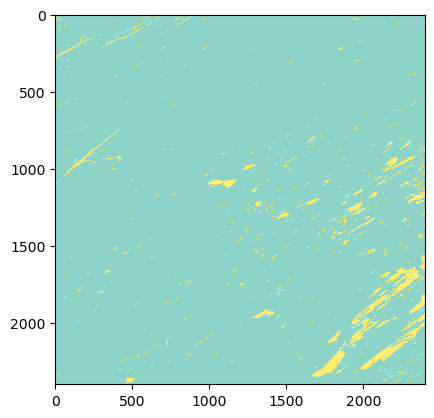

In [15]:
pyplot.imshow(water, cmap = 'Set3', interpolation = 'nearest')

## Solution 8.1

In [16]:
def process_ndvi(filename):
    # Open nvdi dataset
    ndvi = gdal.Open(f'HDF4_EOS:EOS_GRID:{filename}:MODIS_Grid_16DAY_500m_VI:"500m 16 days NDVI"')
    
    #cnvert to float
    ndvi = ndvi.ReadAsArray().astype(np.float32)

    # Open the pixel reliability subdataset
    qa = gdal.Open(f'HDF4_EOS:EOS_GRID:{filename}:MODIS_Grid_16DAY_500m_VI:"500m 16 days pixel reliability"')
    qa = qa.ReadAsArray()

    # mask all but qa of 0/1
    ndvi[(qa != 0) & (qa != 1)] = np.nan

    # rescale to real NDVI values
    ndvi = ndvi * 0.0001

    return ndvi


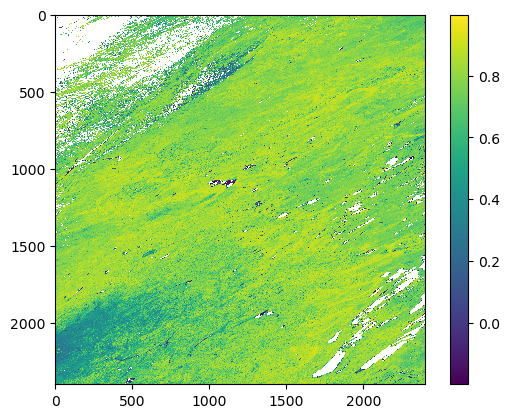

In [17]:
filename = 'data/MOD13A1.A2000193.h11v03.061.2020051154615.hdf'
result = process_ndvi(filename)

pyplot.imshow(result, interpolation='nearest')
pyplot.colorbar()


---

## Problem 8.2: Applying a Land-Cover Mask

Using the MODIS MCD12Q1 data, create a single NumPy array that can be used to mask out:

- "Water bodies"
- Ice or snow
- Urban areas
- Barren pixels

The array should be a binary (0 or 1) array where 1 corresponds to the undesirable land-cover classes.

**Write a Python script (`*.py` file) that combines everything you've done so far:**

1. Reads in a single MOD13A1 image.
2. Masks out pixels according to their "pixel reliability"
3. Masks out pixels from undesirable land-cover classes (see above).

**These steps must be implemented as one or more Python functions (using `def` keyword).** The simplest template for your Python script would be something like:

```python
import numpy as np
from osgeo import gdal
from matplotlib import pyplot

NDVI_FILE = ''
LAND_COVER_FILE = ''

def main():
    # Steps 1-3 implemented here
    

if __name__ == '__main__':
    main()
```

**Copy the Python script's contents into a code block in this Notebook for submission.**

---

## Solution 8.2

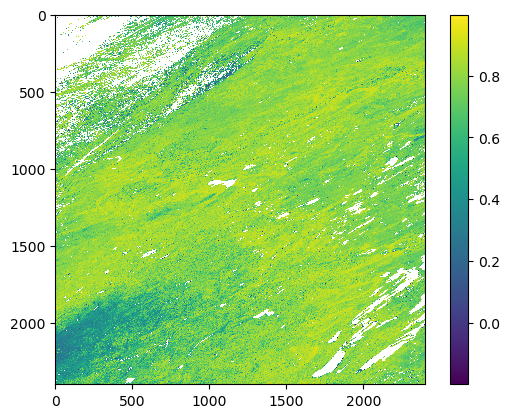

In [18]:
import numpy as np
from osgeo import gdal
from matplotlib import pyplot

NDVI_FILE = 'data/MOD13A1.A2000193.h11v03.061.2020051154615.hdf'
LAND_COVER_FILE = 'data/MCD12Q1.A2015001.h11v03.006.hdf'


def process_ndvi(filename):
     # Open nvdi dataset
    ndvi = gdal.Open(f'HDF4_EOS:EOS_GRID:{filename}:MODIS_Grid_16DAY_500m_VI:"500m 16 days NDVI"')
    
    #cnvert to float
    ndvi = ndvi.ReadAsArray().astype(np.float32)

    # Open the pixel reliability subdataset
    qa = gdal.Open(f'HDF4_EOS:EOS_GRID:{filename}:MODIS_Grid_16DAY_500m_VI:"500m 16 days pixel reliability"')
    qa = qa.ReadAsArray()

    # mask all but qa of 0/1
    ndvi[(qa != 0) & (qa != 1)] = np.nan

    # rescale to real NDVI values
    ndvi = ndvi * 0.0001

    return ndvi


def make_landcover_mask(filename):
    # Open landcover data
    lc = gdal.Open(f'HDF4_EOS:EOS_GRID:"{filename}":MCD12Q1:LC_Type5')
    lc = lc.ReadAsArray()

    # assign 1 to unwanted classes / 0 for wanted classes
    mask = np.where((lc == 0) | (lc == 9) | (lc == 10) | (lc == 11),1,0)

    # set minteger for mask
    mask = mask.astype(np.uint8)

    return mask


def main():
    ndvi = process_ndvi(NDVI_FILE)
    lc_mask = make_landcover_mask(LAND_COVER_FILE)

    # mask out unwanted land cover
    ndvi[lc_mask == 1] = np.nan

    # output
    pyplot.imshow(ndvi, interpolation='nearest')
    pyplot.colorbar()
    pyplot.show()


if __name__ == '__main__':
    main()


## Diagnosing Bottlenecks in Python Code

In a previous class, we saw how multiple Python processes can be used to process raster data in parallel, assuming that our raster processing would be slow if done with a single process.

However, a better plan for your professional Python life, when you think that you might have "slow" code, is to first **profile** your Python code to figure out if and where it's running slow. A **line profiler** is a technique that measures the resources (time and memory) required for each Python statement in your code, helping to identify opportunities to optimize your code.

If you haven't already installed the `line_profiler` module, then type the following into your OSGeo4W Shell and hit ENTER:

```sh
pip install line_profiler
```

Profiling your Python code consists of two steps:

**First, add the `@profile` decorator to the top of each Python function in your Python script (`*.py` file) that you want to get resource statistics about:**

```python
@profile
def some_function():
    ...
    
@profile
def another_function():
    ...
```

A *decorator* in Python is always put on the line before another function definition, pre-prended with the `@` symbol. When the *decorated* function is called, it is actually the *decorator* function that is called first. In this example, `profile()` would be called first and provided with the function `some_function` as its argument. This is how the `line_profiler` module can gather statistics about how `some_function()` executes.

**Second,** from the OSGeo4W Shell, run the line profiler on your script. For example, if your Python script is named `my_script.py`, you would type:

```sh
python -m kernprof -l -v my_script.py
```

**Here's a complete example; the Python script:**

```python
import numpy as np

@profile
def main():
    upper_limit = 1000
    return np.arange(0, upper_limit)
    
    
if __name__ == "__main__":
    main()
```

**And the output from the line profiler (`kernprof`):**

```
C:\Users\Arthur.Endsley>python -m kernprof -l -v temp.py
Wrote profile results to temp.py.lprof
Timer unit: 1e-06 s

Total time: 1.3618e-05 s
File: temp.py
Function: main at line 3

Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
     3                                           @profile
     4                                           def main():
     5         1          1.8      1.8     13.3      upper_limit = 1000
     6         1         11.8     11.8     86.7      return np.arange(0, upper_limit)
```

In this example, we can see that the Python interpreter spent 86.7% of its time on calling `np.arange()` (Line 6) and only 13.3% of its time on creating the variabile `upper_limit` (Line 5). If this wasn't just a toy example, and if we found that the function was running long, we would want to focus any optimization efforts on Line 6, where the interpreter spent the most time.

---

## Problem 8.3: Profiling Your Python Script

**Use the line profiler on the Python script your wrote for Problem 8.2. Copy and paste the output into this Notebook for submission.**

What part of your script takes longest to run?

**Hint:** To copy text from the OSGeo4W Shell: 1) Highlight the text you want to copy; 2) Right-click the *title bar* of the OSGeo4W Shell window; 3) Scroll down to "Edit" and then select "Copy" from the drop-down menu.

## Solution 8.3

C:\Users\theoj\OneDrive - The University of Montana\Courses\GPHY491\Labs\Lab08>python -m kernprof -l -v Solution_8_3.py
C:\PROGRA~1\QGIS34~1.12\apps\Python312\Lib\site-packages\osgeo\gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
Wrote profile results to 'Solution_8_3.py.lprof'
Timer unit: 1e-06 s

Total time: 0.148354 s
File: Solution_8_3.py
Function: process_ndvi at line 15

Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
    15                                           @profile
    16                                           def process_ndvi(filename):
    17                                                # Open nvdi dataset
    18         1      22639.9  22639.9     15.3      ndvi = gdal.Open(f'HDF4_EOS:EOS_GRID:{filename}:MODIS_Grid_16DAY_500m_VI:"500m 16 days NDVI"')
    19
    20                                               #cnvert to float
    21         1      75143.6  75143.6     50.7      ndvi = ndvi.ReadAsArray().astype(np.float32)
    22
    23                                               # Open the pixel reliability subdataset
    24         1      17694.3  17694.3     11.9      qa = gdal.Open(f'HDF4_EOS:EOS_GRID:{filename}:MODIS_Grid_16DAY_500m_VI:"500m 16 days pixel reliability"')
    25         1      19718.1  19718.1     13.3      qa = qa.ReadAsArray()
    26
    27                                               # mask all but qa of 0/1
    28         1       6796.6   6796.6      4.6      ndvi[(qa != 0) & (qa != 1)] = np.nan
    29
    30                                               # rescale to real NDVI values
    31         1       6359.0   6359.0      4.3      ndvi = ndvi * 0.0001
    32
    33         1          2.2      2.2      0.0      return ndvi

Total time: 0.0543683 s
File: Solution_8_3.py
Function: make_landcover_mask at line 35

Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
    35                                           @profile
    36                                           def make_landcover_mask(filename):
    37                                               # Open landcover data
    38         1       1849.8   1849.8      3.4      lc = gdal.Open(f'HDF4_EOS:EOS_GRID:"{filename}":MCD12Q1:LC_Type5')
    39         1      34314.9  34314.9     63.1      lc = lc.ReadAsArray()
    40
    41                                               # assign 1 to unwanted classes / 0 for wanted classes
    42         1      14831.2  14831.2     27.3      mask = np.where((lc == 0) | (lc == 9) | (lc == 10) | (lc == 11),1,0)
    43
    44                                               # set minteger for mask
    45         1       3371.2   3371.2      6.2      mask = mask.astype(np.uint8)
    46
    47         1          1.2      1.2      0.0      return mask

Total time: 1.731 s
File: Solution_8_3.py
Function: main at line 49

Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
    49                                           @profile
    50                                           def main():
    51         1     148539.6 148539.6      8.6      ndvi = process_ndvi(NDVI_FILE)
    52         1      54544.3  54544.3      3.2      lc_mask = make_landcover_mask(LAND_COVER_FILE)
    53
    54                                               # mask out unwanted land cover
    55         1       2823.7   2823.7      0.2      ndvi[lc_mask == 1] = np.nan
    56
    57                                               # output
    58         1     122074.9 122074.9      7.1      pyplot.imshow(ndvi, interpolation='nearest')
    59         1      13772.9  13772.9      0.8      pyplot.colorbar()
    60         1    1389248.2 1.39e+06     80.3      pyplot.show()

The part of the script that takes the longest, is the code that outputs the final map visualization `pyplot.show()` in main(). It took about 4/5ths of the total time to run main(), which makes intuitive sense because of the time needed to gather all the plot pixels and display them for visualization on the computer screen. Other parts of the code with the longest running line was the raster processing steps and reading the NDVI data with `ndvi.ReadAsArray().astype(np.float32)` in `process_ndvi()`.

---

## Calculating Trends in NDVI

You should now have a script that takes in a MOD13A1 file, masks out pixels based on "pixel reliability," and applies a land-cover type mask. Now we're ready to calculate trends in NDVI!

Remember the `linear_trend()` function we defined in the **"Raster Data Analysis in Python, Part 2"** lesson? Let's make a modification to that function here...

In [19]:
from scipy import stats

def linear_trend3(block, years = np.arange(2000, 2024, 2)):
    '''
    Parameters
    ----------
    block : numpy.ndarray
        An (m x n) array, where m is the number of years
    years : numpy.ndarray
        A 1D NumPy array that represents the years
    '''
    # A fancy way of saying call stats.linregress() in a for loop,
    #    once for each pixel in the block
    return np.array([
        stats.linregress(years, block[:,i])[0]
        for i in range(0, block[0].size)
    ])

We want to iterate over all the MOD13A1 files... Change the following, if necessary, so you can get a list of the MOD13A1 files you downloaded.

In [20]:
import glob

# The * symbol below is a wildcard: It matches 0 or more characters in a filename
file_list = glob.glob('data/MOD13A1*.hdf')
file_list.sort()
file_list

['data\\MOD13A1.A2000193.h11v03.061.2020051154615.hdf',
 'data\\MOD13A1.A2002193.h11v03.061.2020077115203.hdf',
 'data\\MOD13A1.A2004193.h11v03.061.2020196083905.hdf',
 'data\\MOD13A1.A2006193.h11v03.061.2020267140733.hdf',
 'data\\MOD13A1.A2008193.h11v03.061.2021102134531.hdf',
 'data\\MOD13A1.A2010193.h11v03.061.2021168184413.hdf',
 'data\\MOD13A1.A2012193.h11v03.061.2021212105123.hdf',
 'data\\MOD13A1.A2014193.h11v03.061.2021259112505.hdf',
 'data\\MOD13A1.A2016193.h11v03.061.2021354115238.hdf',
 'data\\MOD13A1.A2018193.h11v03.061.2021339232403.hdf',
 'data\\MOD13A1.A2020193.h11v03.061.2020340124758.hdf',
 'data\\MOD13A1.A2022193.h11v03.061.2022215010036.hdf']

**Because we're still learning, let's make the problem simpler by resampling our 500-m NDVI images to 1-km resolution.** Before, we did this with `rasterio` and the `rasterio.warp` module. But today, since we're just working with array data, we can try a different and simpler approach.

The `scipy.ndimage` module has a function, `zoom()`, that can do fast nearest-neighbor resampling of arrays.

In [21]:
from scipy.ndimage import zoom

# order = 0 corresponds to Nearest-Neighbor interpolation
result3 = zoom(result, 0.5, order = 0, mode = 'grid-constant', grid_mode = True)
result3.shape

(1200, 1200)

**NOTE:** `result` above should be one of your re-scaled and masked NDVI arrays. This is just an example of how to use the `zoom()` for nearest-neighbor resampling. You'll need to adapt this example to your code in Problem 8.4.

The second argument above, `0.5`, is the scale factor; i.e., we want to scale from 500 m to 1000 m, or $500/1000 = 0.5$. As we can see, the resulting 1-km resolution image has 1200 rows and 1200 columns.

[You can read more about the `zoom()` function in the SciPy documentation.](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.zoom.html)

---

## Problem 8.4: Creating a Multi-Temporal Image Stack

**Write Python code that:**

1. Read in the NDVI and "pixel reliability" datasets; process the NDVI data just like you did in Problem 8.1 with the `process_ndvi()` function.
2. Mask out low-reliability pixels (see Problem 8.1).
3. Mask out pixels with undesirable land-cover types (see Problem 8.2).
4. Resample the 500-m, (2400 x 2400) array to a 1-km, (1200 x 1200) array using `zoom()`.

**Then, stack the 12 annual images together into a (12 x 1200 x 1200) array.**

**Hint:** The `np.stack()` function will stack arrays along a given axis:

In [22]:
a1 = np.arange(0, 10)
print(a1)
a2 = np.arange(50, 60)
print(a2)

[0 1 2 3 4 5 6 7 8 9]
[50 51 52 53 54 55 56 57 58 59]


In [23]:
test = np.stack([a1, a2], axis = 0)
test

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
       [50, 51, 52, 53, 54, 55, 56, 57, 58, 59]])

In [24]:
test.shape

(2, 10)

## Solution 8.4

In [25]:
import glob
from scipy.ndimage import zoom

def build_ndvi_stack():
    file_list = glob.glob('data/MOD13A1*.hdf')
    file_list.sort()

    lc_mask = make_landcover_mask(LAND_COVER_FILE)
    stack_list = []

    for filename in file_list:
        ndvi = process_ndvi(filename)
        ndvi[lc_mask == 1] = np.nan
        ndvi_1km = zoom(ndvi, 0.5, order=0, mode='grid-constant', grid_mode=True)
        stack_list.append(ndvi_1km)

    ndvi_stack = np.stack(stack_list, axis=0)
    return ndvi_stack

ndvi_stack = build_ndvi_stack()
ndvi_stack.shape


(12, 1200, 1200)